# Pipeline de Dados com SIDRA - Censo Demográfico 2022

### Objetivo:
Extrair e tratar dados domiciliares para análise do perfil de aquecimento de água por região brasileira.

### Fontes:
- Censo Demográfico 2022 (Universo — tabelas agregadas)
  - Tabelas disponíveis via SIDRA:
    - 6326 — Tipo de domicílio
    - 6803 — Forma de abastecimento de água
    - 4712 — Domicílios e moradores
- PNAD Contínua:
    - Utilizada em substituição ao Censo 2022 para rendimento,
     pois os microdados da amostra do Censo 2022, que
     incluem a variável de renda domiciliar, não foram
     liberados pelo IBGE até a data deste projeto.
    - 7395 — Rendimento médio mensal real domiciliar per capita (variável 4196)

### Plataforma:
IBGE - Sistema IBGE de Recuperação Automática  https://sidra.ibge.gov.br

In [4]:
# ------------------------------------------------------------
# 1. MONTAGEM DO GOOGLE DRIVE
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ------------------------------------------------------------
# 2. IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------
!pip install sidrapy pandas -q

import sidrapy
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
# ------------------------------------------------------------
# 3. COLETA DOS DADOS
# Extração das tabelas via API do SIDRA
# Nível territorial: 3 = Unidade da Federação (UF)
# ------------------------------------------------------------

# Tabela 6326 com classificação expandida
df_tipo_bruto = sidrapy.get_table(
    table_code="6326",
    territorial_level="3",
    ibge_territorial_code="all",
    period="2022",
    variable="381",
    classifications={"125": "all"}
)

print("Categorias tipo de domicílio:")
print(df_tipo_bruto["D4N"].unique())

Categorias tipo de domicílio:
['Tipo de domicílio' 'Total' 'Casa' 'Casa de vila ou em condomínio'
 'Apartamento' 'Habitação em casa de cômodos ou cortiço'
 'Habitação indígena sem paredes ou maloca'
 'Estrutura residencial permanente degradada ou inacabada']


In [7]:

# Tabela 6803 com classificação expandida
df_agua_bruto = sidrapy.get_table(
    table_code="6803",
    territorial_level="3",
    ibge_territorial_code="all",
    period="2022",
    variable="381",
    classifications={"1821": "all"}
)

print("\nCategorias abastecimento de água:")
print(df_agua_bruto["D4N"].unique())
print(df_agua_bruto.head(10))


Categorias abastecimento de água:
['Existência de ligação à rede geral de distribuição de água e principal forma de abastecimento de água'
 'Total' 'Possui ligação à rede geral e a utiliza como forma principal'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Poço profundo ou artesiano'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Poço raso, freático ou cacimba'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Fonte, nascente ou mina'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Carro-pipa'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Água da chuva armazenada'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Rios, açudes, córregos, lagos e igarapés'
 'Possui ligação à rede geral, mas utiliza principalmente outra forma - Outra'
 'Não possui ligação com a rede geral'
 '

In [8]:
# Tabela 4712 — Domicílios particulares permanentes ocupados,
# moradores e média de moradores
df_moradores_bruto = sidrapy.get_table(
    table_code="4712",
    territorial_level="3",
    ibge_territorial_code="all",
    period="2022",
    variable="allxp"
)

In [9]:
# Tabela 7395 — PNAD Contínua
# Rendimento médio mensal real domiciliar per capita por UF (em Reais)
# Utilizada em substituição à variável de rendimento do
# Censo Demográfico 2022, cujos microdados da amostra
# — que incluem renda domiciliar — não foram liberados
# pelo IBGE até a data de desenvolvimento deste projeto.
# variable="4196": Rendimento médio mensal real domiciliar per capita (Reais)
df_renda_bruto = sidrapy.get_table(
    table_code="7395",
    territorial_level="3",
    ibge_territorial_code="all",
    period="last",
    variable="4196"
)

In [10]:
# ------------------------------------------------------------
# 4. INSPEÇÃO INICIAL
# Verificar estrutura, tipos e volume de cada tabela
# ------------------------------------------------------------

print("=== TIPO DE DOMICÍLIO ===")
print(df_tipo_bruto.head())
print(df_tipo_bruto.info())

print("\n=== ABASTECIMENTO DE ÁGUA ===")
print(df_agua_bruto.head())
print(df_agua_bruto.info())

print("\n=== MORADORES ===")
print(df_moradores_bruto.head())
print(df_moradores_bruto.info())

print("\n=== RENDIMENTO ===")
print(df_renda_bruto.head())
print(df_renda_bruto.info())


=== TIPO DE DOMICÍLIO ===
                           NC                    NN  \
0  Nível Territorial (Código)     Nível Territorial   
1                           3  Unidade da Federação   
2                           3  Unidade da Federação   
3                           3  Unidade da Federação   
4                           3  Unidade da Federação   

                           MC                 MN       V  \
0  Unidade de Medida (Código)  Unidade de Medida   Valor   
1                        1020           Unidades  555099   
2                        1020           Unidades  502777   
3                        1020           Unidades   13360   
4                        1020           Unidades   38220   

                             D1C                   D1N           D2C   D2N  \
0  Unidade da Federação (Código)  Unidade da Federação  Ano (Código)   Ano   
1                             11              Rondônia          2022  2022   
2                             11              Ro

In [11]:
# ------------------------------------------------------------
# 5. LIMPEZA E TRATAMENTO
# O sidrapy retorna a primeira linha como metadado — removê-la.
# Renomear colunas, corrigir tipos e eliminar registros inválidos.
# ------------------------------------------------------------

def tratar_sidra(df, nome_valor):
    df = df.iloc[1:].reset_index(drop=True)

    renomear = {
        "D1C": "cod_uf",
        "D1N": "uf",
        "D2N": "ano",
        "D3N": "variavel",
        "D4C": "cod_categoria",
        "D4N": "categoria",   # tipo de domicílio, abastecimento, etc.
        "V"  : nome_valor
    }
    df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

    df["cod_uf"]    = df["cod_uf"].astype(str).str.zfill(2)
    df[nome_valor]  = pd.to_numeric(df[nome_valor], errors="coerce")
    df              = df.dropna(subset=[nome_valor]).reset_index(drop=True)

    return df


# Reaplicar o tratamento com a função corrigida
# Reaplicar tratamento
df_tipo = tratar_sidra(df_tipo_bruto, "qtd_domicilios")
df_agua = tratar_sidra(df_agua_bruto, "qtd_domicilios")
df_moradores = tratar_sidra(df_moradores_bruto, "valor")
df_renda     = tratar_sidra(df_renda_bruto,     "rendimento_medio_pc")

# A tabela 7395 retorna as dimensões em ordem diferente das tabelas do Censo:
# nela D2N é a descrição da variável e D3N é o ano. A função genérica os rotula
# de forma trocada — corrigir para que "ano" contenha de fato o ano.
df_renda["ano"] = df_renda["variavel"]
df_renda = df_renda[["cod_uf", "uf", "ano", "rendimento_medio_pc"]]

# Confirmar categorias disponíveis
print("Categorias — tipo de domicílio:")
print(df_tipo["categoria"].unique())

Categorias — tipo de domicílio:
['Total' 'Casa' 'Casa de vila ou em condomínio' 'Apartamento'
 'Habitação em casa de cômodos ou cortiço'
 'Habitação indígena sem paredes ou maloca'
 'Estrutura residencial permanente degradada ou inacabada']


In [12]:
# ------------------------------------------------------------
# 6. VERIFICAÇÃO PÓS-LIMPEZA
# Confirmar que os dados estão íntegros após o tratamento
# ------------------------------------------------------------

print("=== TIPO DE DOMICÍLIO — tratado ===")
print(df_tipo.head())
print(df_tipo.describe())

print("\n=== ABASTECIMENTO DE ÁGUA — tratado ===")
print(df_agua.head())
print(df_agua.describe())

print("\n=== MORADORES — tratado ===")
print(df_moradores.head())
print(df_moradores.describe())

print("\n=== RENDIMENTO — tratado ===")
print(df_renda.head())
print(df_renda.describe())

=== TIPO DE DOMICÍLIO — tratado ===
  NC                    NN    MC        MN  qtd_domicilios cod_uf        uf  \
0  3  Unidade da Federação  1020  Unidades        555099.0     11  Rondônia   
1  3  Unidade da Federação  1020  Unidades        502777.0     11  Rondônia   
2  3  Unidade da Federação  1020  Unidades         13360.0     11  Rondônia   
3  3  Unidade da Federação  1020  Unidades         38220.0     11  Rondônia   
4  3  Unidade da Federação  1020  Unidades           615.0     11  Rondônia   

    D2C   ano  D3C                                      variavel  \
0  2022  2022  381  Domicílios particulares permanentes ocupados   
1  2022  2022  381  Domicílios particulares permanentes ocupados   
2  2022  2022  381  Domicílios particulares permanentes ocupados   
3  2022  2022  381  Domicílios particulares permanentes ocupados   
4  2022  2022  381  Domicílios particulares permanentes ocupados   

  cod_categoria                                categoria  
0          2932      

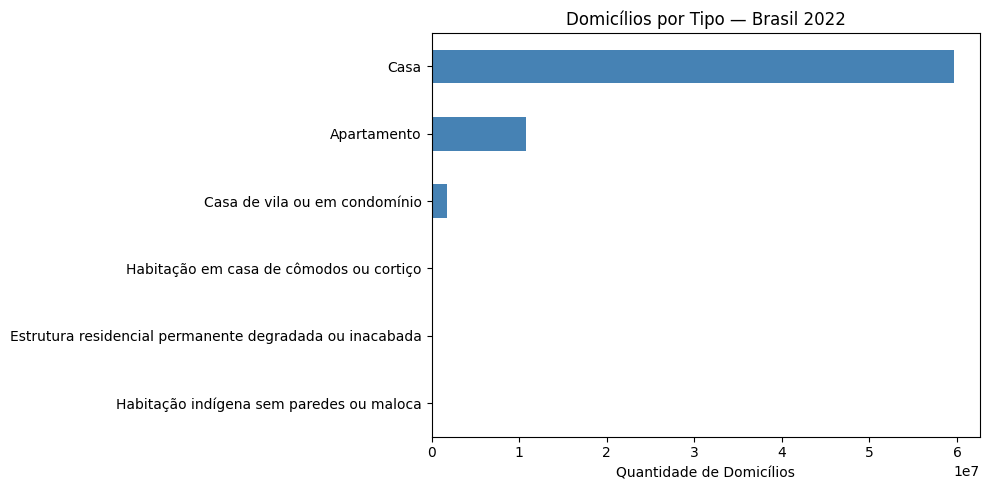

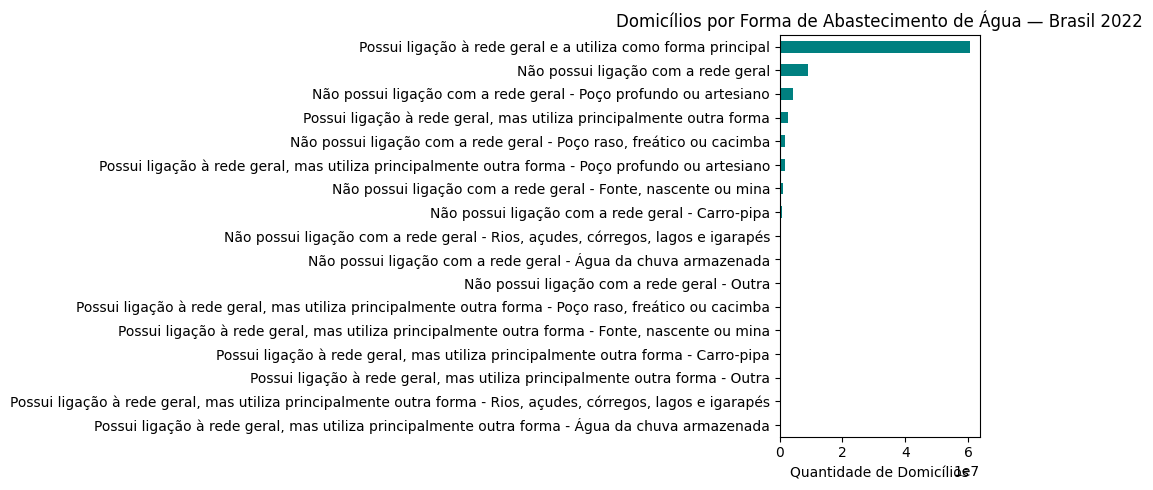

In [13]:
# ------------------------------------------------------------
# 7. VISUALIZAÇÕES INICIAIS
# Quais tipos de domicílio predominam no Brasil?
# ------------------------------------------------------------


df_tipo_total = (
    df_tipo[df_tipo["categoria"] != "Total"]
    .groupby("categoria")["qtd_domicilios"]
    .sum()
    .sort_values(ascending=True)
)

df_tipo_total.plot(kind="barh", figsize=(10, 5), color="steelblue")
plt.title("Domicílios por Tipo — Brasil 2022")
plt.xlabel("Quantidade de Domicílios")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Visualização — abastecimento de água
df_agua_total = (
    df_agua[df_agua["categoria"] != "Total"]
    .groupby("categoria")["qtd_domicilios"]
    .sum()
    .sort_values(ascending=True)
)

df_agua_total.plot(kind="barh", figsize=(10, 5), color="teal")
plt.title("Domicílios por Forma de Abastecimento de Água — Brasil 2022")
plt.xlabel("Quantidade de Domicílios")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------
# 8. EXPORTAÇÃO
# Salvar os dados tratados em CSV para uso nas etapas seguintes
# ------------------------------------------------------------

df_tipo.to_csv("/content/drive/MyDrive/dados_projeto_ciencia_dados/censo2022_tipo_domicilio.csv",      index=False, encoding="utf-8-sig")
df_agua.to_csv("/content/drive/MyDrive/dados_projeto_ciencia_dados/censo2022_abastecimento_agua.csv",  index=False, encoding="utf-8-sig")
df_moradores.to_csv("/content/drive/MyDrive/dados_projeto_ciencia_dados/censo2022_moradores.csv",       index=False, encoding="utf-8-sig")
df_renda.to_csv("/content/drive/MyDrive/dados_projeto_ciencia_dados/pnadc_rendimento_domiciliar.csv", index=False, encoding="utf-8-sig")

print("Arquivos exportados com sucesso.")

Arquivos exportados com sucesso.
